In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [3]:
import pandas as pd
df = pd.read_csv(path + '/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


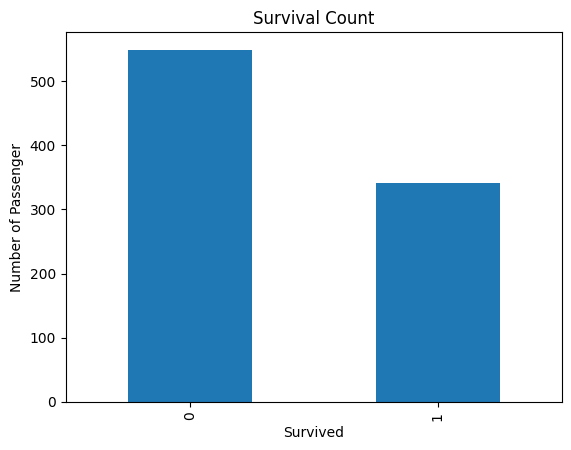

In [9]:
import matplotlib.pyplot as plt

df['Survived'].value_counts().plot(kind="bar")

plt.xlabel("Survived")
plt.ylabel("Number of Passenger")
plt.title("Survival Count")
plt.show()

In [10]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


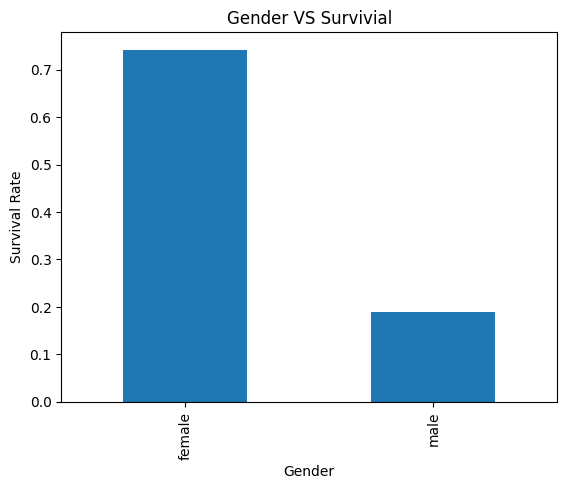

In [11]:
df.groupby("Sex")['Survived'].mean().plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.title("Gender VS Survivial")
plt.show()

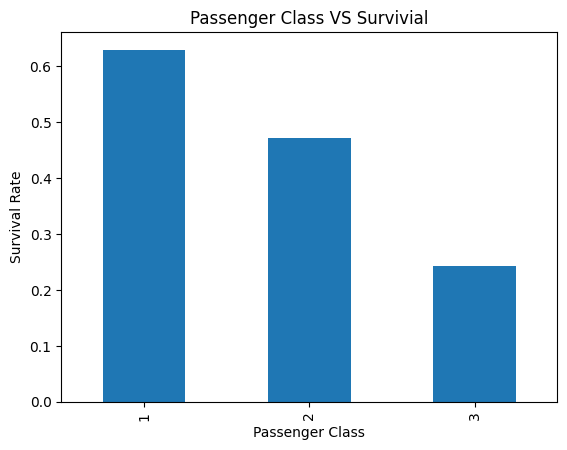

In [12]:
df.groupby("Pclass")['Survived'].mean().plot(kind='bar')

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Passenger Class VS Survivial")
plt.show()

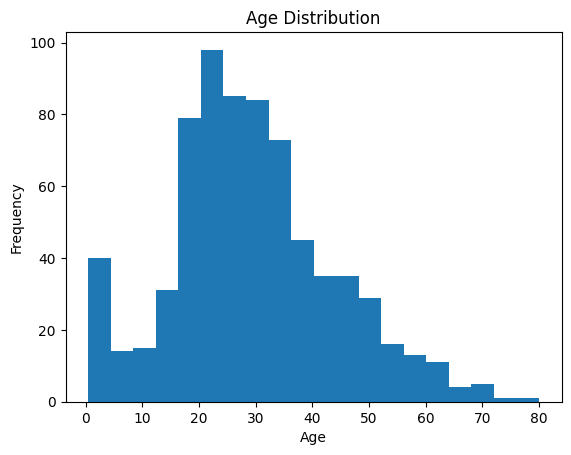

In [13]:
df["Age"].plot(kind='hist', bins=20)

plt.xlabel("Age")
plt.title("Age Distribution")
plt.show()

In [14]:
data = df[["Pclass", "Sex", 'Age', "SibSp", "Parch", "Fare", "Embarked", "Survived"]]

In [15]:
data.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2
Survived,0


In [17]:
data['Age']  = data["Age"].fillna(data["Age"].median())

/tmp/ipykernel_2386/1295809066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age']  = data["Age"].fillna(data["Age"].median())


In [18]:
data.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2
Survived,0


In [19]:
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

/tmp/ipykernel_2386/1853598016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])


In [20]:
data.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Survived,0


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    object 
 7   Survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [22]:
data["Sex"] = data["Sex"].map({
    "male": 0,
    "female": 1
})

/tmp/ipykernel_2386/4078268658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Sex"] = data["Sex"].map({


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    int64  
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    object 
 7   Survived  891 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 55.8+ KB


In [24]:
data["Embarked"] = data["Embarked"].map({
    "S": 0,
    "C":1,
    "Q": 2
})

/tmp/ipykernel_2386/3190745165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Embarked"] = data["Embarked"].map({


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    int64  
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    int64  
 7   Survived  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [26]:
X = data[["Pclass", "Sex","Age","SibSp","Parch","Fare","Embarked"]]
y = data['Survived']

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state= 42
)

In [29]:
#Model 1 : Decision Tree

from sklearn.tree import DecisionTreeClassifier

In [30]:
dt_model = DecisionTreeClassifier(random_state= 42)

In [31]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [34]:
dt_preds = dt_model.predict(X_test)

In [35]:
dt_preds

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0])

In [36]:
y_test

,Survived
709,1
439,0
840,0
720,1
39,1
...,...
821,1
633,0
456,0
500,0


In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [38]:
dt_accuracy = accuracy_score(y_test, dt_preds)

print(dt_accuracy)

0.7388059701492538


In [40]:
print(confusion_matrix(y_test, dt_preds))

[[122  35]
 [ 35  76]]


In [41]:
print(classification_report(y_test, dt_preds))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78       157
           1       0.68      0.68      0.68       111

    accuracy                           0.74       268
   macro avg       0.73      0.73      0.73       268
weighted avg       0.74      0.74      0.74       268



In [42]:
#Model 2: Random Forest

from sklearn.ensemble import RandomForestClassifier

In [43]:
rf_model = RandomForestClassifier(n_estimators= 100, random_state=42)

In [44]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
rf_preds = rf_model.predict(X_test)

In [46]:
rf_accuracy = accuracy_score(y_test, rf_preds)
print(rf_accuracy)

0.7910447761194029


In [47]:
print(confusion_matrix(y_test, rf_preds))

[[131  26]
 [ 30  81]]


In [49]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       157
           1       0.76      0.73      0.74       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



In [50]:
result = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})
result

,Model,Accuracy
0,Decision Tree,0.738806
1,Random Forest,0.791045


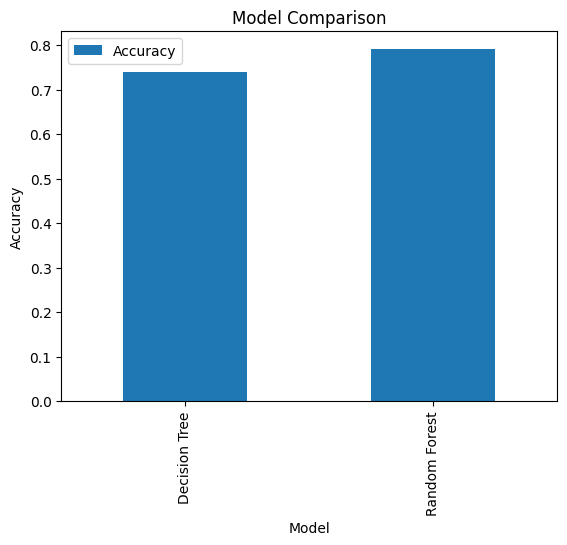

In [52]:
result.plot(kind="bar", x="Model", y="Accuracy")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [54]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
5,Fare,0.263813
1,Sex,0.255407
2,Age,0.254749
0,Pclass,0.092513
3,SibSp,0.052650
6,Embarked,0.041795
4,Parch,0.039073


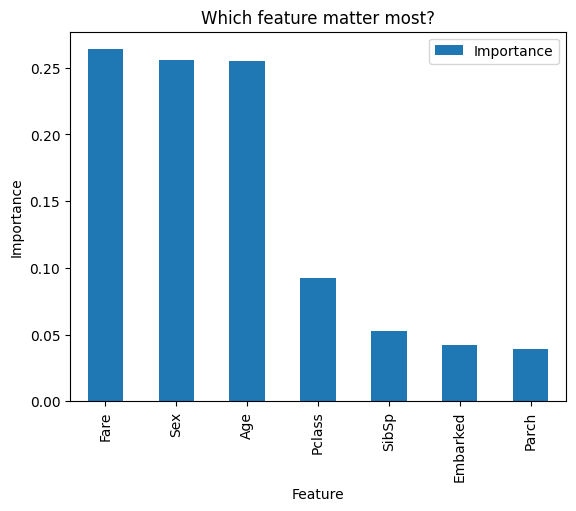

In [55]:
importance.plot(kind="bar", x="Feature", y="Importance")
plt.ylabel("Importance")
plt.title("Which feature matter most?")
plt.show()

In [58]:
new_passenger_m = pd.DataFrame({
    "Pclass": [3],
    "Sex": [0],
    "Age": [25],
    "SibSp": [1],
    "Parch": [0],
    "Fare": [50],
    "Embarked": [2]
})

In [59]:
prediction = rf_model.predict(new_passenger_m)

if prediction[0] == 1:
  print("Survived")
else:
  print("Not Survivied")

Not Survivied


In [61]:
probability = rf_model.predict_proba(new_passenger)

print(probability)

print("Not Survived", probability[0][0])
print("Survived", probability[0][1])

[[0.3 0.7]]
Not Survived 0.3
Survived 0.7


In [62]:
probability = rf_model.predict_proba(new_passenger_m)

print(probability)

print("Not Survived", probability[0][0])
print("Survived", probability[0][1])

[[0.82 0.18]]
Not Survived 0.82
Survived 0.18
